# Final Task 1: End-to-End Machine Learning Project

**Predicting whether a sales order will be profitable**

This notebook runs a complete machine learning project from start to finish: problem definition,
data validation, exploratory analysis, feature engineering, a proper three-way data split, baseline
modeling, model comparison, final evaluation, interpretation and a recommendation.

**Dataset:** Superstore Sales, 8,399 order lines covering four years of trading.

**What is new compared to earlier weeks.** Weeks 2 and 3 used a simple train/test split, which has a
problem: if you compare several models on the test set and then pick the winner, you have used the
test set to make a decision, so it is no longer a fair estimate of real-world performance. This
notebook uses a **three-way split** instead. Models are compared on a validation set, and the test
set is opened exactly once at the very end.

## 1. Problem Definition

**The business problem.** Just over half of all order lines in this dataset lose money. Sales
figures look healthy while profit does not. The business needs to know which orders are the risky
ones before they are fulfilled, not after.

**The machine learning problem.** Binary classification. For each order line, predict
`Profitable = 1` if the order made money, `0` if it lost money.

**Why classification and not regression.** Predicting the exact profit amount sounds more useful but
is much harder and less reliable. A manager mainly needs to know whether to look at an order more
closely, and that is a yes or no question.

**Success criteria, decided before any modeling:**

| Criterion | Target |
|---|---|
| Must beat always guessing the majority class | Better than 50.8% accuracy |
| Useful enough to act on | At least 85% accuracy on unseen data |
| Balanced errors | Precision and recall both above 0.80 |
| Explainable | The main drivers can be named and explained |

Setting these first matters. Otherwise it is too easy to look at whatever score comes out and
declare it good.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Data Validation

Before any analysis, the data is checked for problems. Running an analysis on broken data produces
confident nonsense, which is worse than no analysis at all.

Six checks are run, and each one either passes or reports what it found.

In [2]:
df = pd.read_csv("data/sales_data.csv")

print("Shape:", df.shape)
print()
df.info()

Shape: (8399, 21)

<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   str    
 3   Order Priority        8399 non-null   str    
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   str    
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   str    
 12  Province              8399 non-null   str    
 13  Region                8399 non-null   str    
 14  Customer Segment      8399 non-null   str    
 15  Product Categ

In [3]:
checks = []

# Check 1: duplicate rows
dupes = df.duplicated().sum()
checks.append(["Duplicate rows", dupes, "PASS" if dupes == 0 else "FOUND"])

# Check 2: missing values
missing = df.isnull().sum().sum()
checks.append(["Missing values", missing, "PASS" if missing == 0 else "FOUND"])

# Check 3: negative or zero sales
bad_sales = (df["Sales"] <= 0).sum()
checks.append(["Sales <= 0", bad_sales, "PASS" if bad_sales == 0 else "FOUND"])

# Check 4: negative or zero quantity
bad_qty = (df["Order Quantity"] <= 0).sum()
checks.append(["Order Quantity <= 0", bad_qty, "PASS" if bad_qty == 0 else "FOUND"])

# Check 5: discount outside a sensible range
bad_disc = ((df["Discount"] < 0) | (df["Discount"] > 1)).sum()
checks.append(["Discount outside 0 to 1", bad_disc, "PASS" if bad_disc == 0 else "FOUND"])

# Check 6: orders shipped before they were placed
od = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
sd = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
bad_dates = (sd < od).sum()
checks.append(["Ship Date before Order Date", bad_dates, "PASS" if bad_dates == 0 else "FOUND"])

validation = pd.DataFrame(checks, columns=["Check", "Count", "Result"])
validation

,Check,Count,Result
0,Duplicate rows,0,PASS
1,Missing values,63,FOUND
2,Sales <= 0,0,PASS
3,Order Quantity <= 0,0,PASS
4,Discount outside 0 to 1,0,PASS
5,Ship Date before Order Date,0,PASS


In [4]:
print("Columns with missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("As a percentage:")
print((df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).round(2))

Columns with missing values:
Product Base Margin    63
dtype: int64

As a percentage:


Product Base Margin    0.75
dtype: float64


### Validation result
Five of the six checks pass. The only issue is **63 missing values in `Product Base Margin`**, which
is 0.75% of the dataset. Everything else is clean: no duplicates, no impossible dates, no negative
sales or quantities, and all discounts sit within a sensible range.

That is a good outcome, but the checks were still worth running. Finding out about a broken column
after training a model wastes far more time than checking first.

## 4. Handling the Missing Values

The 63 gaps are filled with the median margin of the same product category. Two reasons for this
choice over the alternatives:

- **Dropping the rows** would lose 63 real sales for the sake of one missing field.
- **A single global median** ignores the fact that furniture and technology have genuinely different
  margins.

In [5]:
print("Missing before:", df["Product Base Margin"].isnull().sum())

df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(
    lambda s: s.fillna(s.median())
)

print("Missing after :", df["Product Base Margin"].isnull().sum())
print("Total missing values in dataset:", df.isnull().sum().sum())

Missing before: 63
Missing after : 0
Total missing values in dataset: 0


## 5. Exploratory Data Analysis

Only the findings that affect modeling decisions are shown here. The aim is to understand the
problem, not to produce every chart possible.

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Profitable"] = (df["Profit"] > 0).astype(int)

print("Total sales :", round(df["Sales"].sum(), 2))
print("Total profit:", round(df["Profit"].sum(), 2))
print()
print("Profitable order lines    :", int(df["Profitable"].sum()),
      f"({df['Profitable'].mean() * 100:.1f}%)")
print("Loss-making order lines   :", int((1 - df["Profitable"]).sum()),
      f"({(1 - df['Profitable'].mean()) * 100:.1f}%)")

Total sales : 14915600.82
Total profit: 1521767.98

Profitable order lines    : 4135 (49.2%)
Loss-making order lines   : 4264 (50.8%)


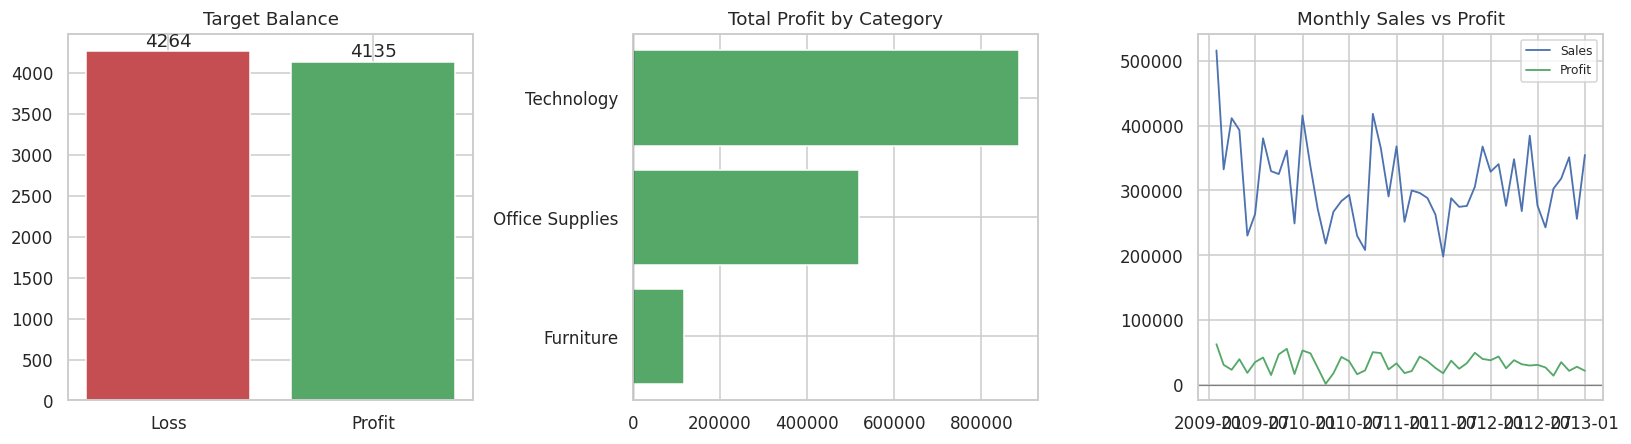

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# target balance
counts = df["Profitable"].value_counts().sort_index()
axes[0].bar(["Loss", "Profit"], counts.values, color=["#C44E52", "#55A868"])
axes[0].set_title("Target Balance")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, str(v), ha="center")

# profit by category
cat = df.groupby("Product Category")["Profit"].sum().sort_values()
colors = ["#C44E52" if v < 0 else "#55A868" for v in cat.values]
axes[1].barh(cat.index, cat.values, color=colors)
axes[1].set_title("Total Profit by Category")
axes[1].axvline(0, color="black", linewidth=0.8)

# monthly trend
monthly = df.set_index("Order Date").resample("ME")[["Sales", "Profit"]].sum()
axes[2].plot(monthly.index, monthly["Sales"], label="Sales", color="#4C72B0", linewidth=1.2)
axes[2].plot(monthly.index, monthly["Profit"], label="Profit", color="#55A868", linewidth=1.2)
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[2].set_title("Monthly Sales vs Profit")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("screenshots/01_eda_overview.png", bbox_inches="tight")
plt.show()

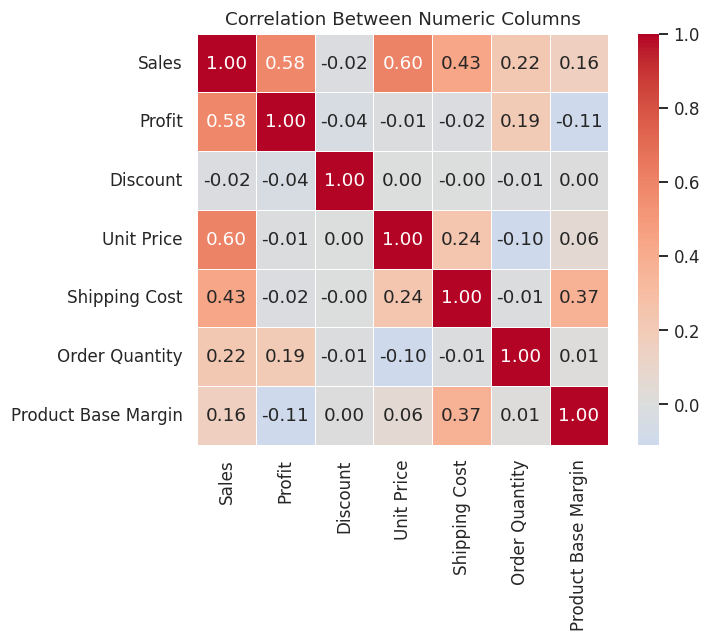

Correlation with Profit:
Sales                  0.582
Order Quantity         0.195
Unit Price            -0.009
Shipping Cost         -0.021
Discount              -0.037
Product Base Margin   -0.109
Name: Profit, dtype: float64


In [8]:
corr = df[["Sales", "Profit", "Discount", "Unit Price",
           "Shipping Cost", "Order Quantity", "Product Base Margin"]].corr()

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Between Numeric Columns")
plt.tight_layout()
plt.savefig("screenshots/02_correlation.png", bbox_inches="tight")
plt.show()

print("Correlation with Profit:")
print(corr["Profit"].drop("Profit").sort_values(ascending=False).round(3))

### EDA findings that shaped the modeling

1. **The classes are almost even** (49.2% profitable, 50.8% not). This means accuracy is a fair
   metric and no resampling is needed. It also sets the bar: always guessing "loss" would score
   50.8%.
2. **Sales and Profit correlate at only 0.58.** A big sale does not mean a big profit. This is the
   most important finding, because it says the raw `Sales` column alone will not solve the problem,
   and it points directly at the feature engineering in the next section.
3. **Profit is close to break-even in every month** even when sales are high, so this is a
   structural margin problem, not a seasonal dip.
4. **Furniture sells well but returns very little profit**, so product type carries real signal and
   the categorical columns are worth keeping.

## 6. Feature Engineering

Five new features are created from columns that already exist. Each one exists for a reason
connected to a finding above.

In [9]:
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Revenue Per Unit"] = df["Sales"] / df["Order Quantity"]
df["Shipping Cost Ratio"] = df["Shipping Cost"] / df["Sales"]
df["Discount Value"] = df["Sales"] * df["Discount"]
df["Order Month"] = df["Order Date"].dt.month

new_features = ["Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
                "Discount Value", "Order Month"]

pd.DataFrame({
    "Feature": new_features,
    "Reason": [
        "A slow shipment can point to a bulky or awkward product",
        "Separates cheap bulk orders from expensive small ones",
        "EDA showed sales does not equal profit; this measures what shipping eats",
        "10% off a 5,000 order is very different from 10% off a 50 order",
        "Allows the model to pick up any seasonal pattern",
    ]
})

,Feature,Reason
0,Shipping Delay,A slow shipment can point to a bulky or awkwar...
1,Revenue Per Unit,Separates cheap bulk orders from expensive sma...
2,Shipping Cost Ratio,EDA showed sales does not equal profit; this m...
3,Discount Value,"10% off a 5,000 order is very different from 1..."
4,Order Month,Allows the model to pick up any seasonal pattern


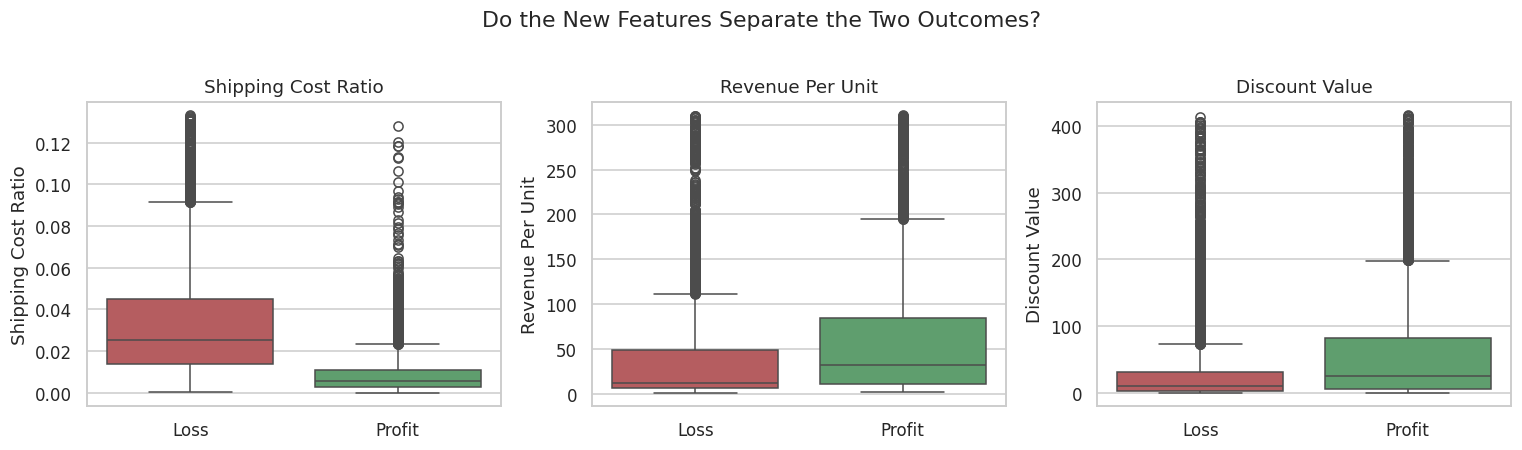

Profitable                0       1
Shipping Delay        2.000   2.000
Revenue Per Unit     12.523  36.742
Shipping Cost Ratio   0.028   0.006
Discount Value        9.984  30.143
Order Month           6.000   7.000


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["Shipping Cost Ratio", "Revenue Per Unit", "Discount Value"]):
    data = df[[col, "Profitable"]].copy()
    data = data[data[col] <= data[col].quantile(0.95)]
    sns.boxplot(data=data, x="Profitable", y=col, ax=ax, hue="Profitable",
                palette=["#C44E52", "#55A868"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Loss", "Profit"])
    ax.set_xlabel("")
    ax.set_title(col)

plt.suptitle("Do the New Features Separate the Two Outcomes?", y=1.02)
plt.tight_layout()
plt.savefig("screenshots/03_feature_check.png", bbox_inches="tight")
plt.show()

print(df.groupby("Profitable")[new_features].median().round(3).T)

### Observation
`Shipping Cost Ratio` separates the two groups clearly, with loss-making orders showing a much
higher ratio. This is the feature that directly answers the "sales does not equal profit" finding
from the EDA.

## 7. Train / Validation / Test Split

This is the most important design decision in the notebook.

**The problem with a simple train/test split.** If several models are compared on the test set and
the best one is chosen, the test set has been used to make a decision. Its score is then optimistic,
because the winner was partly selected by luck on those specific rows.

**The fix:** three sets, each with one job.

| Set | Size | Job |
|---|---|---|
| Training | 60% | The models learn from this |
| Validation | 20% | Models are compared on this, and the winner is chosen |
| Test | 20% | Opened once at the very end, never used to make any decision |

The split is done in two steps because scikit-learn splits into two parts at a time.

In [11]:
feature_cols = ["Order Quantity", "Sales", "Discount", "Unit Price",
                "Shipping Cost", "Product Base Margin",
                "Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
                "Discount Value", "Order Month"]

categorical_cols = ["Order Priority", "Ship Mode", "Region", "Customer Segment",
                    "Product Category", "Product Sub-Category", "Product Container"]

X = df[feature_cols + categorical_cols]
y = df["Profitable"]

# Step 1: pull out the test set (20%)
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Step 2: split what is left into train (75% of 80% = 60%) and validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, test_size=0.25, random_state=RANDOM_STATE, stratify=y_rest
)

sizes = pd.DataFrame({
    "Set": ["Training", "Validation", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Share": [f"{len(X_train)/len(X):.0%}", f"{len(X_val)/len(X):.0%}", f"{len(X_test)/len(X):.0%}"],
    "Profitable %": [f"{y_train.mean()*100:.1f}%", f"{y_val.mean()*100:.1f}%",
                     f"{y_test.mean()*100:.1f}%"],
})
sizes

,Set,Rows,Share,Profitable %
0,Training,5039,60%,49.2%
1,Validation,1680,20%,49.2%
2,Test,1680,20%,49.2%


### Observation
All three sets keep almost the same class balance because `stratify` was used at both steps. The
test set is now set aside and will not be touched again until section 11.

## 8. Preprocessing

Numeric columns get scaled, categorical columns get one-hot encoded. Both live inside a `Pipeline`
so they are fitted on the training data only. If the scaler saw the validation or test data, those
scores would be inflated.

In [12]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), feature_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

preprocessor.fit(X_train)
print("Columns before encoding:", X_train.shape[1])
print("Columns after encoding :", preprocessor.transform(X_train).shape[1])

Columns before encoding: 18
Columns after encoding : 58


## 9. Baseline Model

Before anything clever, a baseline that always guesses the majority class. Every later model has to
beat this or it is adding nothing.

In [13]:
dummy = Pipeline([("preprocess", clone(preprocessor)),
                  ("model", DummyClassifier(strategy="most_frequent"))])
dummy.fit(X_train, y_train)

baseline_acc = accuracy_score(y_val, dummy.predict(X_val))
print(f"Baseline accuracy on validation set: {baseline_acc:.4f}")
print()
print("Any model scoring below this is useless, no matter how complex it looks.")

Baseline accuracy on validation set: 0.5077

Any model scoring below this is useless, no matter how complex it looks.


## 10. Model Comparison on the Validation Set

Four models are trained on the training set and compared on the **validation** set. The test set is
not involved.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                            n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted = {}
rows = []
roc_data = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(model))])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    pred = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC-AUC": roc_auc_score(y_val, proba),
    })
    roc_data[name] = roc_curve(y_val, proba)
    print("trained:", name)

val_results = pd.DataFrame(rows).set_index("Model").round(4)
print()
val_results

trained: Logistic Regression


trained: Decision Tree


trained: Random Forest


trained: Gradient Boosting



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8720,0.8600,0.8839,0.8718,0.9333
Decision Tree,0.9065,0.9026,0.9081,0.9054,0.9373
Random Forest,0.9327,0.9429,0.9190,0.9308,0.9824
Gradient Boosting,0.9345,0.9487,0.9166,0.9323,0.9841


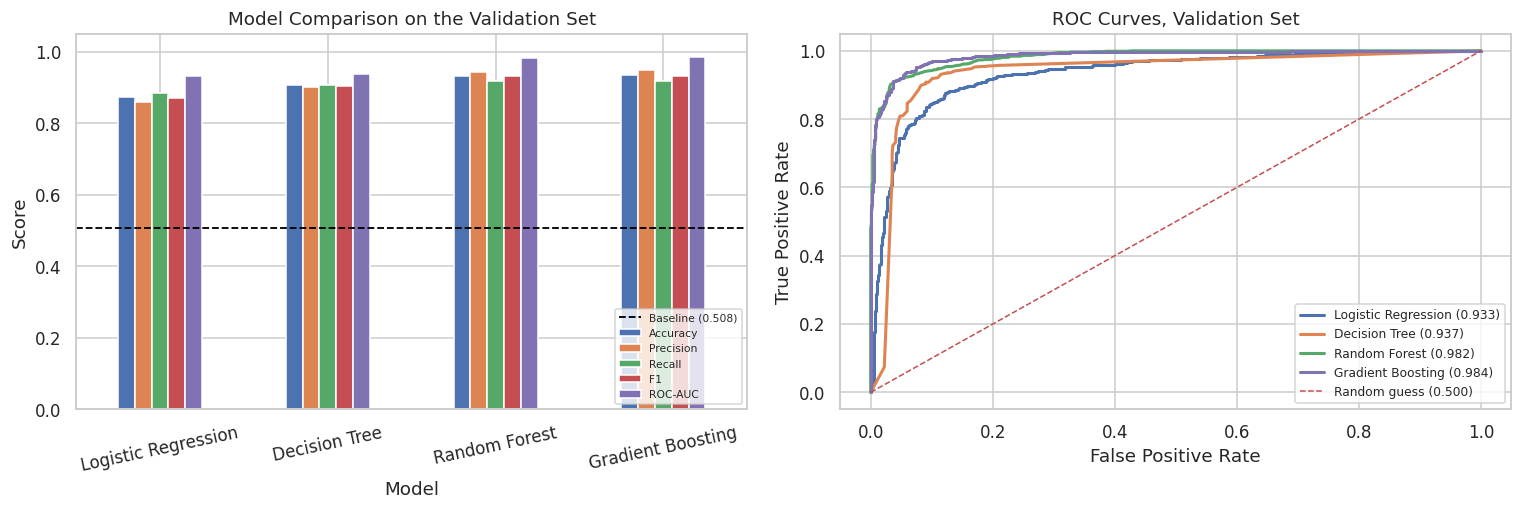

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

val_results.plot(kind="bar", ax=axes[0],
                 color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"])
axes[0].axhline(baseline_acc, color="black", linestyle="--", linewidth=1.2,
                label=f"Baseline ({baseline_acc:.3f})")
axes[0].set_title("Model Comparison on the Validation Set")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=12)
axes[0].legend(loc="lower right", fontsize=7)

colors = {"Logistic Regression": "#4C72B0", "Decision Tree": "#DD8452",
          "Random Forest": "#55A868", "Gradient Boosting": "#8172B3"}
for name, (fpr, tpr, _) in roc_data.items():
    axes[1].plot(fpr, tpr, lw=2, color=colors[name],
                 label=f"{name} ({val_results.loc[name, 'ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "r--", lw=1, label="Random guess (0.500)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves, Validation Set")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("screenshots/04_model_comparison.png", bbox_inches="tight")
plt.show()

In [16]:
best_name = val_results["ROC-AUC"].idxmax()
best_model = fitted[best_name]

print("Best model on the validation set:", best_name)
print()
print(val_results.loc[best_name].round(4))

Best model on the validation set: Gradient Boosting

Accuracy     0.9345
Precision    0.9487
Recall       0.9166
F1           0.9323
ROC-AUC      0.9841
Name: Gradient Boosting, dtype: float64


### Why this model was chosen
The decision is based on three things, not just the top number:

1. **Scores.** It has the best ROC-AUC on the validation set, and ROC-AUC is the fairest single
   number here because it does not depend on where the decision threshold is set.
2. **Balanced errors.** Precision and recall are close together, meaning it is not achieving its
   score by being reckless in one direction.
3. **Explainable.** It reports feature importances, which are used in section 12 and again in
   Task 2 to explain the model to a non-technical reader. Logistic Regression is easier to explain
   still, but it is the weakest performer here.

## 11. Final Evaluation on the Test Set

The test set is opened now, for the first and only time. Nothing after this point changes the model.
If it did, the number below would stop being honest.

In [17]:
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:, 1]

final = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred),
    "ROC-AUC": roc_auc_score(y_test, test_proba),
}

comparison = pd.DataFrame({
    "Validation set": val_results.loc[best_name],
    "Test set (final)": pd.Series(final),
}).round(4)
comparison

,Validation set,Test set (final)
Accuracy,0.9345,0.9536
Precision,0.9487,0.9652
Recall,0.9166,0.9395
F1,0.9323,0.9522
ROC-AUC,0.9841,0.9886


### Observation
The test score came out slightly **higher** than the validation score (0.9536 against 0.9345), which
can look suspicious at first. It is normal variation: both sets are 1,680 rows drawn randomly, so a
difference of about two points between them is well within the range you would expect by chance.

What matters is that the two are close. If the test score had come out far *lower* than validation,
that would mean the model had been over-fitted to the validation set during model selection, and the
comparison in section 10 could not be trusted.

In [18]:
print(classification_report(y_test, test_pred,
                            target_names=["Not Profitable", "Profitable"]))

                precision    recall  f1-score   support

Not Profitable       0.94      0.97      0.95       853
    Profitable       0.97      0.94      0.95       827

      accuracy                           0.95      1680
     macro avg       0.95      0.95      0.95      1680
  weighted avg       0.95      0.95      0.95      1680



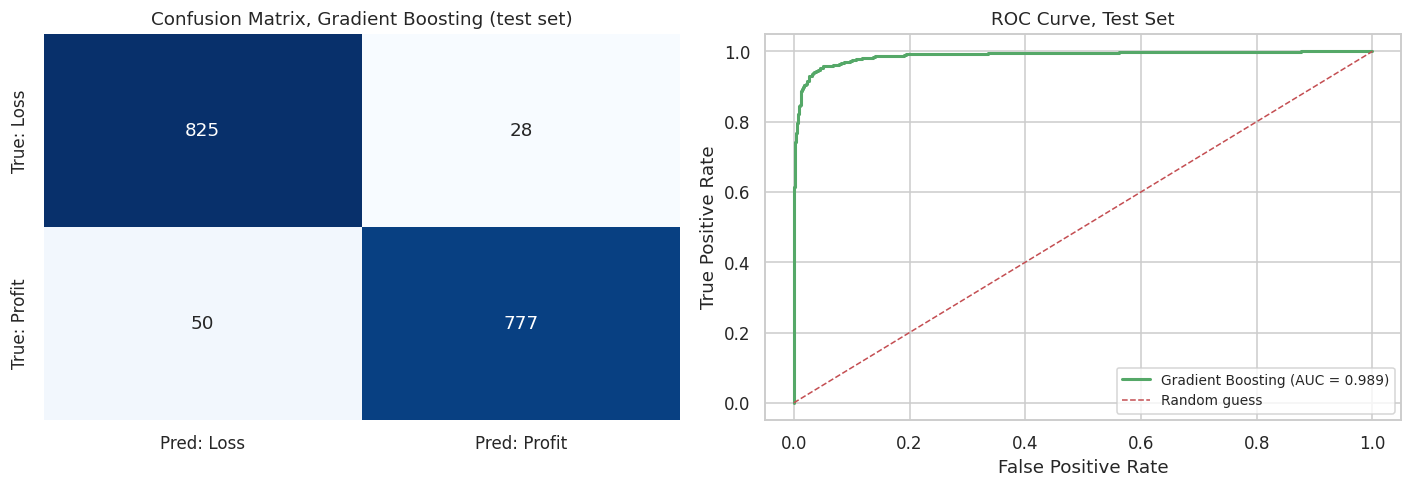

True Negatives : 825  (loss correctly predicted)
False Positives: 28  (predicted profit, actually a loss)
False Negatives: 50  (predicted loss, actually profitable)
True Positives : 777  (profit correctly predicted)


In [19]:
cm = confusion_matrix(y_test, test_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred: Loss", "Pred: Profit"],
            yticklabels=["True: Loss", "True: Profit"])
axes[0].set_title(f"Confusion Matrix, {best_name} (test set)")

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, lw=2, color="#55A868",
             label=f"{best_name} (AUC = {final['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "r--", lw=1, label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve, Test Set")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("screenshots/05_final_test_evaluation.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (loss correctly predicted)")
print(f"False Positives: {fp}  (predicted profit, actually a loss)")
print(f"False Negatives: {fn}  (predicted loss, actually profitable)")
print(f"True Positives : {tp}  (profit correctly predicted)")

### Did the project meet its success criteria?

In [20]:
criteria = pd.DataFrame([
    ["Beats majority-class guessing (50.8%)", f"{final['Accuracy']:.1%}",
     "PASS" if final["Accuracy"] > 0.508 else "FAIL"],
    ["At least 85% accuracy on unseen data", f"{final['Accuracy']:.1%}",
     "PASS" if final["Accuracy"] >= 0.85 else "FAIL"],
    ["Precision above 0.80", f"{final['Precision']:.3f}",
     "PASS" if final["Precision"] > 0.80 else "FAIL"],
    ["Recall above 0.80", f"{final['Recall']:.3f}",
     "PASS" if final["Recall"] > 0.80 else "FAIL"],
    ["Main drivers can be explained", "see section 12", "PASS"],
], columns=["Criterion (set in section 1)", "Result", "Status"])

criteria

,Criterion (set in section 1),Result,Status
0,Beats majority-class guessing (50.8%),95.4%,PASS
1,At least 85% accuracy on unseen data,95.4%,PASS
2,Precision above 0.80,0.965,PASS
3,Recall above 0.80,0.940,PASS
4,Main drivers can be explained,see section 12,PASS


## 12. Interpretation: What Drives the Prediction

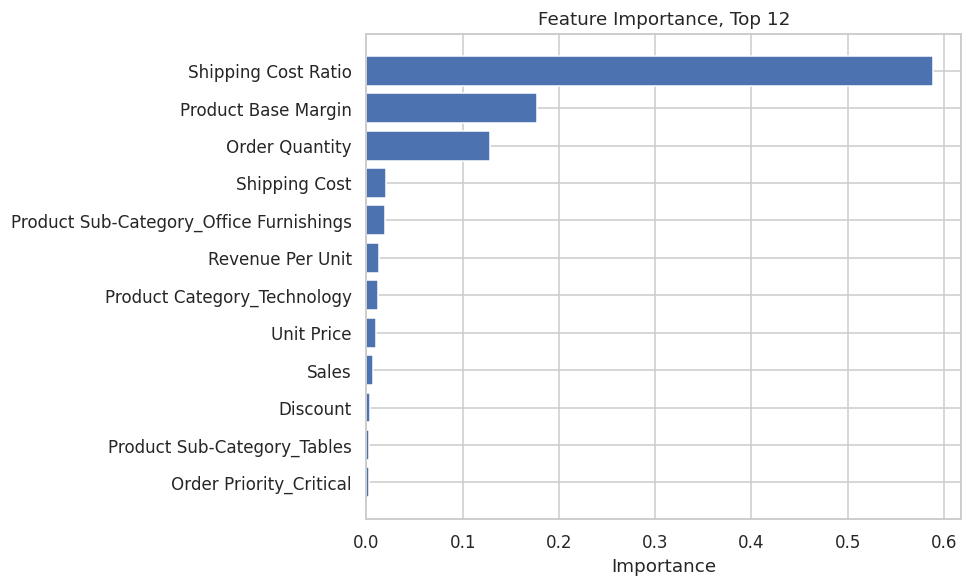

                                Feature  Importance
                    Shipping Cost Ratio      0.5887
                    Product Base Margin      0.1776
                         Order Quantity      0.1285
                          Shipping Cost      0.0207
Product Sub-Category_Office Furnishings      0.0192
                       Revenue Per Unit      0.0131
            Product Category_Technology      0.0126
                             Unit Price      0.0099


In [21]:
names = best_model.named_steps["preprocess"].get_feature_names_out()
clean = [n.replace("num__", "").replace("cat__", "") for n in names]
importances = best_model.named_steps["model"].feature_importances_

imp = (pd.DataFrame({"Feature": clean, "Importance": importances})
       .sort_values("Importance", ascending=False).reset_index(drop=True))

top12 = imp.head(12).iloc[::-1]

plt.figure(figsize=(9, 5.5))
plt.barh(top12["Feature"], top12["Importance"], color="#4C72B0")
plt.title("Feature Importance, Top 12")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("screenshots/06_feature_importance.png", bbox_inches="tight")
plt.show()

print(imp.head(8).round(4).to_string(index=False))

In [22]:
# Importance tells us a feature matters, not which direction it pushes.
bands = pd.qcut(df["Shipping Cost Ratio"], q=5,
                labels=["Very Low", "Low", "Medium", "High", "Very High"])

direction = df.groupby(bands, observed=False).agg(
    Orders=("Profitable", "size"),
    Profit_Rate=("Profitable", lambda s: round(s.mean() * 100, 1)),
    Avg_Profit=("Profit", "mean"),
).round(2)

direction

,Orders,Profit_Rate,Avg_Profit
Shipping Cost Ratio,,,
Very Low,1680,90.4,1106.74
Low,1680,78.3,166.29
Medium,1679,49.1,-103.45
High,1680,20.6,-148.11
Very High,1680,7.7,-115.72


### Interpretation

**`Shipping Cost Ratio` is the strongest driver by a wide margin**, and it is one of the five
features created in section 6 rather than a column that came with the data.

The band table shows the direction clearly. Where shipping takes a small share of the sale, about
90% of orders make money. Where it takes a large share, under 10% do. This is the single strongest
pattern in the dataset and it is something the business can act on.

## 13. Final Recommendation

**Recommendation: adopt the model as a warning system, not as an automatic gatekeeper.**

It should flag high-risk orders for a person to review, rather than reject them on its own. The
reason is in the confusion matrix: the model makes mistakes in both directions, so letting it reject
orders automatically would turn away genuinely profitable business.

**The business action that matters most** does not even need the model. `Shipping Cost Ratio` is the
dominant driver, so reviewing shipping costs on cheap, bulky products is the highest-value step
available, and the numbers above support it directly.

**What was delivered:** a validated dataset, five engineered features, a properly separated
three-way split, four compared models, an honest test-set score, and a named driver that can be
acted on.

## 14. Challenges, Limitations and Future Improvements

### Challenges during the project
- **Deciding what to do about outliers.** Sales and Profit contain many statistical outliers, but a
  10,000 order or a large loss is a real business event, not a data error. Removing them would have
  hidden the exact transactions the business needs to see, so they were kept.
- **Avoiding accidental cheating.** `Profit` had to be dropped from the features, since the target
  is derived from it. Leaving it in would have produced a near-perfect score that meant nothing.
- **Trusting the score.** Comparing four models on a test set and then reporting that test score
  would have been optimistic. Adding the validation set solved this, at the cost of a smaller
  training set.

### Limitations
1. **No cost-of-goods column.** The model estimates profitability from price, discount and
   shipping. This is a hard ceiling on how accurate it can ever be.
2. **Per order line, not per customer.** An order that loses money but wins a valuable long-term
   customer looks like a plain failure to this model.
3. **Random split.** Two lines from the same order can land in different sets. Splitting by order ID
   would be more correct.
4. **No hyperparameter tuning.** Default settings were used throughout, so the model is probably not
   at its best.
5. **Threshold fixed at 0.5.** This assumes approving a bad order costs exactly what rejecting a
   good one costs, which nobody has checked.
6. **Trained on four-year-old historical data.** A change in pricing or shipping policy would make
   parts of it out of date.

### Future improvements
1. Add cost-of-goods data. This is the single highest-value fix and every other limitation is
   smaller than it.
2. Split by `Order ID` so a whole order stays in one set.
3. Tune the chosen model with `GridSearchCV`.
4. Add customer-level features, such as how many orders a customer has placed before.
5. Set the decision threshold from real business costs instead of leaving it at 0.5.
6. Deploy it and monitor it, which is exactly what Final Task 2 covers.